## 실행 환경 확인

이 셀은 Jupyter Notebook과 Python 실행 환경이 정상적으로 동작하는지 확인하기 위한 예시 코드임.

- Python이 정상적으로 실행되는지 점검
- 노트북 셀 실행이 되는지 확인
- 이후 분석 코드가 문제없이 돌기 위한 기본 체크

In [2]:
print("hello world")

hello world


## 데이터 샘플 확인

이 코드는 실제 GA4 이벤트 데이터의 형태를 살펴보는 단계임.

- 테이블에서 일부 행을 불러와 데이터가 제대로 들어왔는지 확인



In [3]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT *
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_20210131`
LIMIT 10
"""

df = client.query(query).to_dataframe()
print(df.head())
print(df.columns.tolist())

  event_date   event_timestamp       event_name  \
0   20210131  1612069510766593        page_view   
1   20210131  1612069529243877           scroll   
2   20210131  1612069515781635        page_view   
3   20210131  1612069530073506  user_engagement   
4   20210131  1612069510766593    session_start   

                                        event_params  \
0  [{'key': 'gclid', 'value': {'string_value': No...   
1  [{'key': 'debug_mode', 'value': {'string_value...   
2  [{'key': 'debug_mode', 'value': {'string_value...   
3  [{'key': 'page_location', 'value': {'string_va...   
4  [{'key': 'ga_session_number', 'value': {'strin...   

   event_previous_timestamp  event_value_in_usd  event_bundle_sequence_id  \
0                      <NA>                 NaN                6595101026   
1                      <NA>                 NaN                9011338476   
2                      <NA>                 NaN               -6830522854   
3                      <NA>                 NaN 

##  이벤트별 집계 확인

이 코드는 어떤 이벤트가 얼마나 많이 발생했는지 확인하는 단계임.

- `event_name` 기준으로 이벤트 수 집계
- 각 이벤트의 총 발생 건수 확인
- 사용자 수(`unique_users`)도 함께 보며 이벤트의 실제 참여 규모를 파악

주요 확인 포인트:
- 어떤 이벤트가 발생하는지
- 사용자 기반으로도 규모가 큰 이벤트가 있는지
- acquisition 분석에서 핵심 이벤트를 선별할 수 있는지

주의 사항:
- first_visit의 이벤트 발생건수가 해당 이벤트를 발생시킨 고유 유저의 수보다 148건이 높게 측정됨 따라서 일부 유저에 대한 중복이 있을 수 있음을 생각해야함

In [4]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    event_name,
    COUNT(*) AS event_count,
    COUNT(DISTINCT user_pseudo_id) AS unique_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
GROUP BY event_name
ORDER BY event_count DESC
"""

df = client.query(query).to_dataframe()
print(df)

             event_name  event_count  unique_users
0             page_view      1350428        269792
1       user_engagement      1058721        213004
2                scroll       493072        138098
3             view_item       386068         61252
4         session_start       354970        267116
5           first_visit       257462        257314
6        view_promotion       190104        102443
7           add_to_cart        58543         12545
8        begin_checkout        38757          9715
9           select_item        31007         13180
10  view_search_results        26172         14449
11    add_shipping_info        19722          9714
12     add_payment_info        13899          5751
13     select_promotion         9450          8164
14             purchase         5692          4419
15                click         1446          1010
16       view_item_list           71            44


##  이벤트 파라미터별 확인

이 코드는 각 이벤트에서 어떤 매개변수들이 얼마나 많이 발생하는지 확인하는 단계임.

- `param.key` 기준으로 어떤 파라미터가 자주 나오는지 집계
- 각 이벤트별로 어떤 정보가 수집되고 있는지 확인

주요 확인 포인트:
- 사용자 유입 경로, 캠페인, 소스 등에 쓰이는 파라미터 키를 찾는지
- acquisition 관련 파라미터가 어떤 이름으로 저장되는지

In [5]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    event_name,
    param.key AS param_key,
    COUNT(*) AS occurrence_count
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`,
UNNEST(event_params) AS param
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
GROUP BY event_name, param_key
ORDER BY event_name, occurrence_count DESC
"""

df = client.query(query).to_dataframe()
print(df)

              event_name          param_key  occurrence_count
0       add_payment_info      page_location             13899
1       add_payment_info         page_title             13899
2       add_payment_info           currency             13899
3       add_payment_info         debug_mode             13899
4       add_payment_info  ga_session_number             13899
..                   ...                ...               ...
275  view_search_results           all_data             17771
276  view_search_results             source               361
277  view_search_results           campaign               361
278  view_search_results             medium               361
279  view_search_results               term                31

[280 rows x 3 columns]


##  first_visit 관련 핵심 파라미터 추출

이 코드는 `first_visit` 이벤트에서 실제로 어떤 파라미터가 중요한지 확인하는 마지막 단계임.

- `first_visit` 이벤트만 필터링
- `occurrence_count` 기준으로 내림차순 정렬
- acquisition 분석에서 가장 자주 확인해야 할 파라미터를 추출

주요 확인 포인트:
- `first_visit` 이벤트에서 어떤 파라미터가 자주 발생하는지
- 유입 경로, 캠페인, 채널 관련 키를 찾는지
- 이후 실제 acquisition 분석의 기준 변수를 정립하는지

In [6]:
first_visit_params = df[df['event_name'] == 'first_visit'].sort_values('occurrence_count', ascending=False)
print(first_visit_params)

     event_name              param_key  occurrence_count
84  first_visit      ga_session_number            257462
85  first_visit          page_location            257462
86  first_visit          ga_session_id            257462
87  first_visit  engaged_session_event            257368
88  first_visit        session_engaged            257178
89  first_visit             page_title            254591
90  first_visit          page_referrer            165332


## 추가 분석 포인트: 상위 컬럼으로 분류되는 유입 변수

신규 유입을 세분화해서 분석할 때, 지역, 채널과 같은 변수는 이벤트 파라미터 안에 있는 값으로 확인되는 것이 아니라, 별도의 상위 컬럼으로 저장돼 있음.

예를 들어:
- 지역 정보는 `geo` 컬럼으로 존재함.
- 채널 정보는 `traffic_source` 컬럼으로 존재함.

즉, `event_params`에서 파라미터를 확인하는 것만으로는 신규 유입의 세부 분류를 이해하기 어렵고, 상위 컬럼을 살펴봐야 함.

In [7]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH weekly AS (
    SELECT
        DATE_TRUNC(PARSE_DATE('%Y%m%d', event_date), WEEK(MONDAY)) AS week_start,
        COUNT(DISTINCT user_pseudo_id) AS new_users
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
        AND event_name = 'first_visit'
    GROUP BY week_start
),
total AS (
    SELECT
        CAST(NULL AS DATE) AS week_start,
        COUNT(DISTINCT user_pseudo_id) AS new_users
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
        AND event_name = 'first_visit'
)
SELECT * FROM weekly
UNION ALL
SELECT * FROM total
ORDER BY week_start IS NULL, week_start
"""

df = client.query(query).to_dataframe()

# week_start가 NULL인 행(합계 행)을 'Total Sum'으로 라벨링
df['week_start'] = df['week_start'].astype(object)
df.loc[df['week_start'].isna(), 'week_start'] = 'Total Sum'

print(df)

    week_start  new_users
0   2020-11-02      16500
1   2020-11-09      14594
2   2020-11-16      16906
3   2020-11-23      18737
4   2020-11-30      21200
5   2020-12-07      27563
6   2020-12-14      24226
7   2020-12-21      17015
8   2020-12-28      16304
9   2021-01-04      22464
10  2021-01-11      21010
11  2021-01-18      20231
12  2021-01-25      18669
13   Total Sum     255369


## 주별 신규 사용자 집계

`event_name = 'first_visit'`인 이벤트를 기준으로, 각 사용자의 첫 방문을 한 번만 계산하여 주별 신규 사용자 수를 집계함.

- 2020년 11월 1일은 일요일이라 주별 집계 기준인 월요일 시작주에 포함되지 않으므로 분석 범위에서 제외함

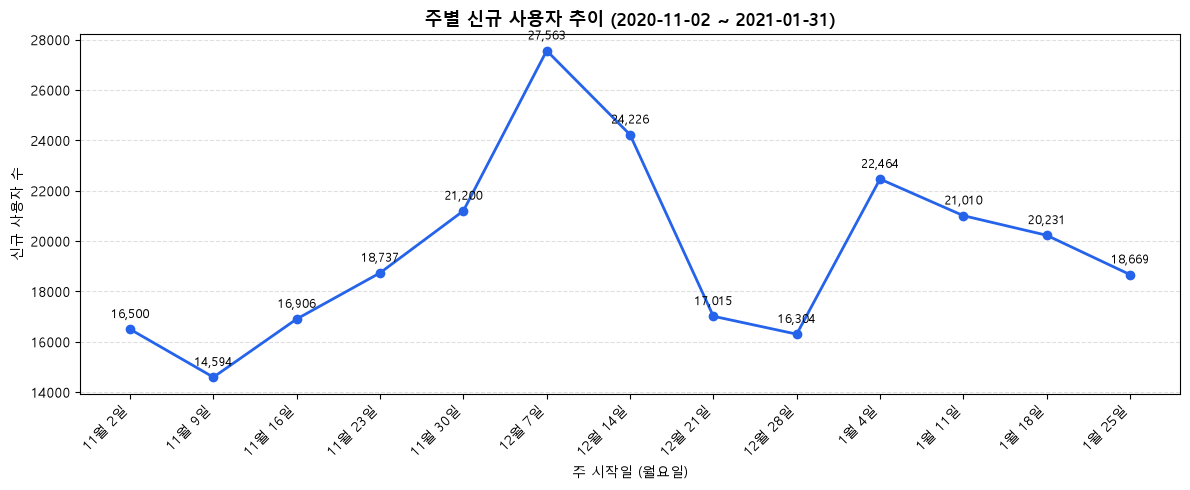

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정 (Windows 기준, Mac은 'AppleGothic'으로 변경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Total Sum 행 제외하고 주별 데이터만 사용
df_weekly = df[df['week_start'] != 'Total Sum'].copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_weekly['week_start'], df_weekly['new_users'], marker='o', linewidth=2, color='#2563eb')

# 각 포인트 위에 값 라벨 표시
for x, y in zip(df_weekly['week_start'], df_weekly['new_users']):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

ax.set_title('주별 신규 사용자 추이 (2020-11-02 ~ 2021-01-31)', fontsize=13, fontweight='bold')
ax.set_xlabel('주 시작일 (월요일)')
ax.set_ylabel('신규 사용자 수')

# x축 눈금을 week_start 값 전부로 명시 지정
ax.set_xticks(df_weekly['week_start'])

# 라벨을 "11월 2일" 형식으로 커스텀 포맷
xtick_labels = [f"{d.month}월 {d.day}일" for d in df_weekly['week_start']]
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('weekly_new_users.png', dpi=150)
plt.show()

### 구간별 가설과 이후 분석 단계

#### 1) 12/7 주 피크는 특정 채널이 견인했을 것이다

11/23 주(18,737)보다 2주 뒤인 12/7 주가 더 높게 나타난 점은, 단순한 블랙프라이데이 효과라기보다 일정 시차가 있는 다른 원인이 있을 가능성이 있음


#### 2) 12/21~12/28 주 급락은 채널별로 다르게 나타날 것이다

연말 하락이 모든 채널에서 동일하게 나타난다면 계절적 소비 패턴으로 볼 수 있지만, 특정 채널만 급락했다면 광고 예산 소진 또는 집행 중단의 영향일 가능성이 큼.


#### 3) 1/4 주 반등은 신규 캠페인 재개 또는 새해 검색 트래픽 때문일 것이다

12/28 주(16,304) 대비 1/4 주(22,464) 급등은 새해 소비 트렌드 변화 또는 광고 재개 효과를 반영했을 가능성이 있음.


#### 4) 이 변동이 특정 지역에 편중되어 있을 것이다

블랙프라이데이, 크리스마스, 새해는 특정 국가에서 더 강하게 나타날 수 있으므로, 지역별 비중을 확인하면 유입 변동의 원인을 더 정확히 추정할 수 있음.


### 이후 분석 단계

가장 우선적으로 검증해야 할 축은 채널임. 채널이 왜 이런 변동이 발생했는지에 더 직접적으로 설명할 가능성이 높기 때문임.

다음 단계는 주별 × 채널 교차 집계로 넘어가, 각 구간에서 어떤 채널이 변동을 주도했는지 확인하는 것임.

이를 통해 상승/하락 구간의 원인을 보다 명확하게 해석할 수 있음.

---

# 채널별 신규 이용자 유입 분석

## 캠페인별 신규 사용자 집계

이 코드는 `first_visit` 이벤트를 기준으로 캠페인별 신규 사용자 수를 집계함.

- `traffic_source.name`별 유입 건수 비교


In [9]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH campaign AS (
    SELECT
        traffic_source.name AS campaign_name,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    GROUP BY campaign_name
),
total AS (
    SELECT
        'Total Sum' AS campaign_name,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
)
SELECT * FROM campaign
UNION ALL
SELECT * FROM total
ORDER BY campaign_name = 'Total Sum', event_cnt DESC
"""

df = client.query(query).to_dataframe()
print(df)

    campaign_name  event_cnt
0       (organic)      98074
1        (direct)      60899
2         <Other>      60141
3      (referral)      36367
4  (data deleted)         35
5       Total Sum     255516


## 매체별 신규 사용자 집계

이 코드는 `first_visit` 이벤트를 기준으로 유입 매체별 신규 사용자 수를 집계함.

- `traffic_source.medium`별 유입 건수 비교
- Organic, Paid, Referral, Direct 등 채널별 규모 파악
- 주별 신규 사용자 변동을 설명하는 주요 매체 확인


In [10]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH medium_group AS (
    SELECT
        traffic_source.medium AS medium,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    GROUP BY medium
),
total AS (
    SELECT
        'Total Sum' AS medium,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
)
SELECT * FROM medium_group
UNION ALL
SELECT * FROM total
ORDER BY medium = 'Total Sum', event_cnt DESC
"""

df = client.query(query).to_dataframe()
print(df)

           medium  event_cnt
0         organic      98074
1          (none)      60899
2         <Other>      46127
3        referral      36367
4             cpc      14013
5  (data deleted)         36
6       Total Sum     255516


## 소스별 신규 사용자 집계

이 코드는 `first_visit` 이벤트를 기준으로 유입 소스별 신규 사용자 수를 집계함.

- `traffic_source.source`별 유입 건수 비교
- 검색엔진, 외부 사이트 등 구체적인 유입 출처 확인
- 동일한 매체 안에서 어떤 소스가 유입을 주도했는지 파악


In [11]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH medium_group AS (
    SELECT
        traffic_source.source AS source,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    GROUP BY source
),
total AS (
    SELECT
        'Total Sum' AS source,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
)
SELECT * FROM medium_group
UNION ALL
SELECT * FROM total
ORDER BY source = 'Total Sum', event_cnt DESC
"""

df = client.query(query).to_dataframe()
print(df)

                            source  event_cnt
0                           google     103676
1                          <Other>      78250
2                         (direct)      60899
3  shop.googlemerchandisestore.com      12656
4                   (data deleted)         35
5                        Total Sum     255516


## 캠페인, 매체, 소스 조합별 신규 사용자 집계

이 코드는 캠페인명, 매체, 소스를 함께 묶어 유입 조합별 신규 사용자 수를 집계함.

- 세 가지 유입 차원을 동시에 비교
- 각 조합의 실제 유입 규모 확인
- 이후 채널 그룹핑과 캠페인 단위 분석 가능 여부 판단에 활용


In [12]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH grouped AS (
    SELECT
        traffic_source.name AS campaign_name,
        traffic_source.medium AS medium,
        traffic_source.source AS source,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    GROUP BY campaign_name, medium, source
),
total AS (
    SELECT
        'Total Sum' AS campaign_name,
        'Total Sum' AS medium,
        'Total Sum' AS source,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
)
SELECT * FROM grouped
UNION ALL
SELECT * FROM total
ORDER BY campaign_name = 'Total Sum', campaign_name ASC, medium ASC
"""

df = client.query(query).to_dataframe()
print(df)

     campaign_name          medium                           source  event_cnt
0   (data deleted)  (data deleted)                   (data deleted)         34
1   (data deleted)  (data deleted)                          <Other>          1
2         (direct)          (none)                         (direct)      60899
3        (organic)         organic                          <Other>       8412
4        (organic)         organic                           google      89662
5       (referral)        referral                          <Other>      23711
6       (referral)        referral  shop.googlemerchandisestore.com      12656
7          <Other>  (data deleted)                   (data deleted)          1
8          <Other>         <Other>                           google          1
9          <Other>         <Other>                          <Other>      46126
10         <Other>             cpc                           google      14013
11       Total Sum       Total Sum                  


### 각 조합 설명

| # | 조합 | 쉬운 설명 |
|---|---|---|
| 0 | (data deleted) / (data deleted) / (data deleted) | 세 필드 모두 프라이버시 설정으로 정보 삭제 |
| 1 | (data deleted) / (data deleted) / \<Other\> | campaign·medium은 삭제, source만 미분류로 남은 극소수 예외 |
| 2 | (direct) / (none) / (direct) | 주소창 직접 입력, 북마크, 카톡·문자 링크 — 추적 신호(리퍼럴 정보) 자체가 없음 |
| 3 | (organic) / organic / \<Other\> | 구글이 아닌 다른 검색엔진(네이버, 빙 등)으로 자연 유입 |
| 4 | (organic) / organic / google | 구글 검색 결과(광고 아님)를 클릭해서 들어옴 — 가장 흔한 유입 |
| 5 | (referral) / referral / \<Other\> | 외부 사이트(블로그·커뮤니티 등) 링크 클릭, 출처는 불명 |
| 6 | (referral) / referral / shop.googlemerchandisestore.com | 사이트 내부 이동인데 리퍼럴로 잘못 잡힌 경우. source가 외부 도메인이 아닌 자기 자신이라 "제3자 소개"라는 referral의 정의를 충족하지 못함 → 제3자 개입 없이 온 Direct의 정의에 더 부합 |
| 7 | \<Other\> / (data deleted) / (data deleted) | name은 미분류, medium·source는 삭제된 극소수 예외 |
| 8 | \<Other\> / \<Other\> / google | 구글에서 온 건 확실하나 방식(medium)은 미분류인 극소수 예외 |
| 9 | \<Other\> / \<Other\> / \<Other\> | 어디서 왔는지 신호는 있으나 GA4가 못 알아본 미분류 유입 (앱 인앱브라우저 등) |
| 10 | \<Other\> / cpc / google | 구글 유료 검색 광고 클릭 (캠페인명이 안 붙어서 \<Other\>) |

### 그룹핑 과정

세부 source는 다르지만 **유입 "방식"(medium) 이 같으면 하나의 채널로 묶는 게 분석에 유리**함.

- **Organic Search**: #3 + #4 → medium=organic 기준으로 통합 (구글이든 아니든 "자연 검색"이라는 본질은 동일)
- **Direct**: #2 + #6 → #6(자사 도메인 셀프 리퍼럴)은 source가 외부가 아닌 자기 자신이라 "제3자 소개" 조건을 충족하지 못하므로, 정의상 Referral이 아닌 Direct로 재분류
- **Paid Search**: #10 단독 (campaign_name이 \<Other\>여도 medium=cpc면 명확히 유료광고)
- **Referral**: #5 단독 (실제 외부 도메인 미상이지만 제3자 개입은 확인됨)
- **Unassigned**: #0, #1, #7, #8, #9 → 전부 합쳐서 "채널 특정 불가"로 처리 (총 46,163건)

**결론: 그룹핑은 `medium` 기준을 기본으로 하되, `source`가 자사 도메인인 경우(#6)만 예외적으로 `source`까지 함께 확인해 Direct로 재분류함.**

### 데이터 상 한계 — 캠페인 단위 분석 불가

- `campaign_name`에 실제 마케팅 캠페인명(예: "2020_black_friday_sale")이 단 한 건도 없고, 전부 GA4 자동 placeholder(`(organic)`, `(direct)`, `<Other>`, `(referral)`, `(data deleted)`)로만 구성됨
- 이는 UTM `utm_campaign` 파라미터가 붙은 유입이 이 데이터셋에 존재하지 않는다는 의미
- 따라서 **"어떤 캠페인이 신규 유입을 얼마나 데려왔는가"와 같은 캠페인 단위 성과 분석은 불가능**
- 대신 `medium`/`source`는 UTM 없이도 브라우저 리퍼러로 자동 판별되므로, **채널(Organic/Direct/Paid/Referral) 단위 분석으로 범위를 한정**하여 진행

In [13]:
from google.cloud import bigquery
import matplotlib.pyplot as plt

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH first_visit_users AS (
  SELECT
    user_pseudo_id,
    traffic_source.source AS source,
    traffic_source.medium AS medium
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE event_name = 'first_visit'
    AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
),

channel_grouped AS (
  SELECT
    user_pseudo_id,
    CASE
      WHEN medium = 'organic' THEN 'Organic Search'
      WHEN medium = 'cpc' THEN 'Paid Search'
      WHEN medium = '(none)' AND source = '(direct)' THEN 'Direct'
      WHEN medium = 'referral' AND source = 'shop.googlemerchandisestore.com' THEN 'Direct'
      WHEN medium = 'referral' THEN 'Referral'
      ELSE 'Unassigned'
    END AS channel_group
  FROM first_visit_users
),

channel_summary AS (
  SELECT
    channel_group,
    COUNT(*) AS user_cnt,
    ROUND(COUNT(*) / SUM(COUNT(*)) OVER() * 100, 1) AS pct
  FROM channel_grouped
  GROUP BY channel_group
),

total AS (
  SELECT
    'Total Sum' AS channel_group,
    SUM(user_cnt) AS user_cnt,
    100.0 AS pct
  FROM channel_summary
)

SELECT * FROM channel_summary
UNION ALL
SELECT * FROM total
ORDER BY channel_group = 'Total Sum', user_cnt DESC
"""

df_channel = client.query(query).to_dataframe()
df_channel

,channel_group,user_cnt,pct
0,Organic Search,98074,38.4
1,Direct,73555,28.8
2,Unassigned,46163,18.1
3,Referral,23711,9.3
4,Paid Search,14013,5.5
5,Total Sum,255516,100.0


### 채널별 신규 이용자 비율 
- GA4의 `first_visit` 이벤트를 조회해 전체 신규 이용자를 추출함.
- 그룹핑 규칙을 기반으로 전체 신규 이용자에 대한 비율 계산

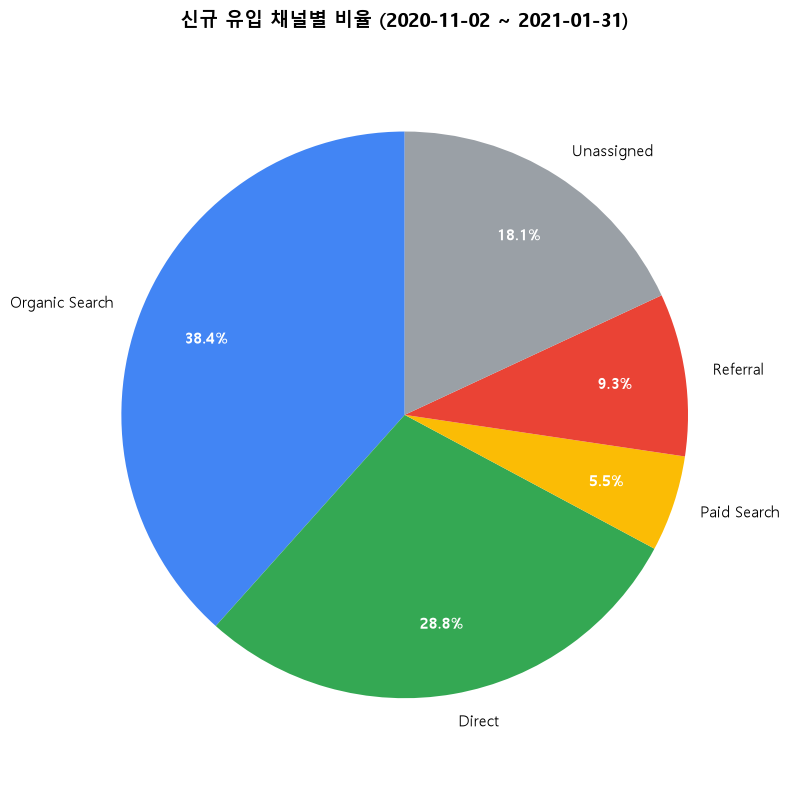

    channel_group  user_cnt   pct
0  Organic Search     98074  38.4
1          Direct     73555  28.8
2     Paid Search     14013   5.5
3        Referral     23711   9.3
4      Unassigned     46163  18.1


In [14]:
# ============================================
# 파이 차트 시각화
# ============================================

# 채널 순서/색상 고정 (일관된 시각화를 위해)
channel_order = ['Organic Search', 'Direct', 'Paid Search', 'Referral', 'Unassigned']
df_channel_sorted = df_channel.set_index('channel_group').reindex(channel_order).reset_index()

colors = ['#4285F4', '#34A853', '#FBBC05', '#EA4335', '#9AA0A6']  # Google 팔레트 + 회색(Unassigned)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    df_channel_sorted['user_cnt'],
    labels=df_channel_sorted['channel_group'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('신규 유입 채널별 비율 (2020-11-02 ~ 2021-01-31)', fontsize=14, fontweight='bold', pad=20)
ax.axis('equal')

plt.tight_layout()
plt.savefig('channel_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_channel_sorted)

In [15]:
from google.cloud import bigquery
import matplotlib.pyplot as plt
import pandas as pd

client = bigquery.Client(project="pro-talon-503713-s3")

# ============================================
# 주별 x 채널별 신규 사용자 집계
# ============================================
query = """
WITH first_visit_users AS (
  SELECT
    user_pseudo_id,
    DATE_TRUNC(PARSE_DATE('%Y%m%d', event_date), WEEK(MONDAY)) AS week_start,
    traffic_source.source AS source,
    traffic_source.medium AS medium
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE event_name = 'first_visit'
    AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
),

channel_grouped AS (
  SELECT
    user_pseudo_id,
    week_start,
    CASE
      WHEN medium = 'organic' THEN 'Organic Search'
      WHEN medium = 'cpc' THEN 'Paid Search'
      WHEN medium = '(none)' AND source = '(direct)' THEN 'Direct'
      WHEN medium = 'referral' AND source = 'shop.googlemerchandisestore.com' THEN 'Direct'
      WHEN medium = 'referral' THEN 'Referral'
      ELSE 'Unassigned'
    END AS channel_group
  FROM first_visit_users
)

SELECT
  week_start,
  channel_group,
  COUNT(*) AS user_cnt
FROM channel_grouped
GROUP BY week_start, channel_group
ORDER BY week_start, channel_group
"""

df_weekly_channel = client.query(query).to_dataframe()
df_weekly_channel

,week_start,channel_group,user_cnt
0,2020-11-02,Direct,4702
1,2020-11-02,Organic Search,6357
2,2020-11-02,Paid Search,947
3,2020-11-02,Referral,1532
4,2020-11-02,Unassigned,2972
...,...,...,...
60,2021-01-25,Direct,5399
61,2021-01-25,Organic Search,7180
62,2021-01-25,Paid Search,1046
63,2021-01-25,Referral,1684


In [16]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    DATE_TRUNC(PARSE_DATE('%Y%m%d', event_date), WEEK(MONDAY)) AS week_start,
    CASE
        WHEN traffic_source.source = 'shop.googlemerchandisestore.com'
            AND traffic_source.medium = 'referral' THEN 'Direct'
        WHEN traffic_source.medium = '(none)'
            AND traffic_source.source = '(direct)' THEN 'Direct'
        WHEN traffic_source.medium = 'organic' THEN 'Organic Search'
        WHEN traffic_source.medium IN ('cpc', 'ppc', 'paidsearch') THEN 'Paid Search'
        WHEN traffic_source.medium = 'referral' THEN 'Referral'
        ELSE 'Unassigned'
    END AS channel,
    COUNT(*) AS new_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    AND event_name = 'first_visit'
GROUP BY week_start, channel
ORDER BY week_start, channel
"""

df_weekly_channel = client.query(query).to_dataframe()

# 피벗: 행=주차, 열=채널, 값=신규 유저 수
df_pivot = df_weekly_channel.pivot_table(
    index='week_start',
    columns='channel',
    values='new_users',
    aggfunc='sum',
    fill_value=0
)

# 5개 채널이 모두 컬럼으로 존재하도록 보정 (특정 주차에 값이 0인 채널이 있으면 컬럼 자체가 누락될 수 있음)
channel_order = ['Organic Search', 'Direct', 'Paid Search', 'Referral', 'Unassigned']
df_pivot = df_pivot.reindex(columns=channel_order, fill_value=0)

print(df_pivot)

channel     Organic Search  Direct  Paid Search  Referral  Unassigned
week_start                                                           
2020-11-02            6357    4702          947      1532        2972
2020-11-09            5571    4182          814      1327        2706
2020-11-16            6506    4942          900      1564        3002
2020-11-23            7204    5371          983      1751        3434
2020-11-30            8211    6095         1250      1903        3750
2020-12-07           10520    7885         1533      2601        5030
2020-12-14            9218    7070         1345      2263        4340
2020-12-21            6590    4768          921      1623        3118
2020-12-28            6256    4711          857      1551        2936
2021-01-04            8768    6467         1207      2006        4025
2021-01-11            8028    6110         1084      2019        3781
2021-01-18            7665    5853         1126      1887        3704
2021-01-25          

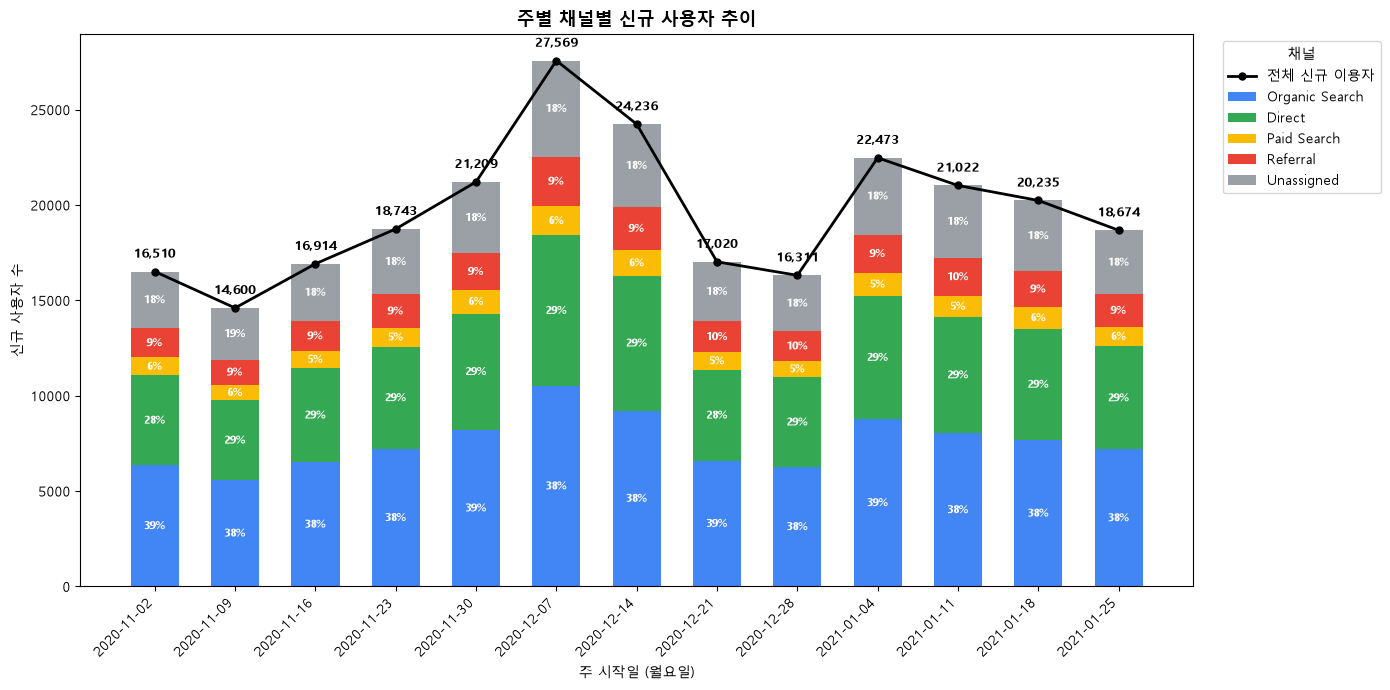

In [17]:
# ============================================
# 주별 채널별 누적 막대 그래프 + 구간별 비율(%) 라벨 + 전체 신규 이용자 라인 그래프
# ============================================

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

channel_order = ['Organic Search', 'Direct', 'Paid Search', 'Referral', 'Unassigned']
colors = {
    'Organic Search': '#4285F4',
    'Direct': '#34A853',
    'Paid Search': '#FBBC05',
    'Referral': '#EA4335',
    'Unassigned': '#9AA0A6'
}

# 주별 총 신규 이용자 수 (라인 그래프용)
weekly_total = df_pivot.sum(axis=1)

# 주별 x 채널별 비율(%) - 라벨 표시용
df_pivot_pct = df_pivot.div(weekly_total, axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))

x_labels = df_pivot.index.astype(str)
bottom = pd.Series([0] * len(df_pivot), index=df_pivot.index)

for channel in channel_order:
    bars = ax.bar(
        x_labels,
        df_pivot[channel],
        bottom=bottom,
        label=channel,
        color=colors[channel],
        width=0.6
    )

    # 각 구간 중앙에 비율(%) 라벨 표시 (구간이 너무 작으면 생략)
    for i, (week, value) in enumerate(df_pivot[channel].items()):
        pct = df_pivot_pct.loc[week, channel]
        if value > 0 and pct >= 4:  # 너무 작은 구간엔 라벨 생략 (겹침 방지)
            y_pos = bottom[week] + value / 2
            ax.text(
                i, y_pos, f'{pct:.0f}%',
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold'
            )

    bottom += df_pivot[channel]

# 전체 신규 이용자 수 라인 그래프 (같은 y축, 누적 막대 상단과 동일선상)
ax.plot(
    x_labels, weekly_total,
    color='black', marker='o', linewidth=2, markersize=5,
    label='전체 신규 이용자', zorder=5
)

for i, (week, total) in enumerate(weekly_total.items()):
    ax.annotate(
        f'{total:,}', (i, total),
        textcoords='offset points', xytext=(0, 10),
        ha='center', fontsize=9, fontweight='bold'
    )

ax.set_title('주별 채널별 신규 사용자 추이', fontsize=13, fontweight='bold')
ax.set_xlabel('주 시작일 (월요일)')
ax.set_ylabel('신규 사용자 수')
ax.legend(title='채널', loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('weekly_channel_stacked_bar_with_pct_and_line.png', dpi=150, bbox_inches='tight')
plt.show()

### 채널별 비율 변동폭

아래 표는 2020-11-02부터 2021-01-25까지 주별 채널 비율의 최솟값과 최댓값을 비교한 내용입니다.

| 채널 | 최솟값 | 최댓값 | 변동폭 | 간단한 해석 |
|---|---:|---:|---:|---|
| Organic Search | 38% | 39% | 1%p | 가장 큰 비중을 유지하며 변동이 작음 |
| Direct | 28% | 29% | 1%p | 두 번째로 큰 비중을 안정적으로 유지함 |
| Paid Search | 5% | 6% | 1%p | 전체 비중은 작지만 주별로 소폭 변동함 |
| Referral | 9% | 10% | 1%p | 대부분 9% 수준이며 일부 주에 10%로 증가함 |
| Unassigned | 18% | 19% | 1%p | 대체로 18% 수준으로 유지되며 일부 주에만 상승함 |

### 결론

**신규 이용자 수의 주별 증감은 채널 구성 변화가 아니라 전체 트래픽 자체의 변동에서 비롯된 것으로 보임.**

- 13주 전 구간에서 5개 채널(Organic Search, Direct, Paid Search, Referral, Unassigned)의 비율이 모두 ±1%p 이내로 거의 고정되어 있었음.
- 신규 이용자가 최저치인 14,600명(11/9 주)에서 최고치인 27,569명(12/7 주)까지 변동하는 동안에도 채널 구성비는 거의 동일하게 유지됨.
- 특정 채널의 광고 집행 또는 중단보다는 모든 채널에 공통으로 영향을 미치는 계절성이나 시즌 이벤트 등이 원인일 가능성을 시사함.

### 가설 검증 결과

- **“12/7 주 피크는 특정 채널이 견인했을 것이다”**: 채널별 비율 변동폭이 1%p 이내로 작아 **기각**됨.
- **“12/21~12/28 급락은 채널별로 다르게 나타날 것이다”**: 채널 구성비가 거의 일정하게 유지되어 **기각**됨.

따라서 해당 기간의 신규 이용자 증감은 특정 채널의 구성 변화보다 전체 유입 규모의 변화로 설명하는 것이 타당함.

### A(고객 유치) 단계 — 데이터 한계로 분석 불가능한 항목

이 데이터셋은 아래 항목들에 대한 원천 데이터가 없어, 실무적으로 중요함에도 분석이 불가능함.

#### 1. CAC (고객획득비용)
- **왜 중요한가**: 채널별로 "얼마나 효율적으로" 신규 유저를 데려왔는지 판단하는 핵심 지표. 유입량이 많아도 비용이 비싸면 비효율적인 채널일 수 있음.
- **왜 불가능한가**: 광고비/캠페인 예산 데이터가 데이터셋에 전혀 포함되어 있지 않음.

#### 2. 캠페인 단위 성과 분석
- **왜 중요한가**: "어떤 캠페인이 신규 유입에 얼마나 견인했는가" — 마케팅 예산 재배분 의사결정에 직결되는 실무 핵심 분석
- **왜 불가능한가**: `campaign_name`에 실제 UTM 캠페인명이 단 1건도 없고, 전부 GA4 자동 입력 값(`(organic)`, `(direct)`, `<Other>` 등)으로만 구성됨.

#### 3. Social 채널 유입
- **왜 중요한가**: 이커머스에서도 인스타/페이스북 광고, 인플루언서 마케팅을 통한 유입은 일반적으로 중요한 채널 중 하나
- **왜 불가능한가**: `medium` 고윳값에 social 관련 값이 이 데이터셋(기간) 안에 아예 존재하지 않음

#### 4. Unassigned(18.1%)의 실제 유입 경로
- **왜 중요한가**: 신규 유저 5명 중 1명 가까이가 "어디서 왔는지" 특정이 안 됨 — 이 비중이 크면 채널 전략 수립 자체의 신뢰도가 떨어짐
- **왜 불가능한가**: `traffic_source` 신호 자체가 GA4 내부적으로 미분류 처리되어, 원인이 되는 데이터가 없어 역추적이 불가능함

---

# 디바이스별 신규 이용자 유입 분석

### 그룹별 신규 이용자 집계 함수 정의
GA4 이벤트 테이블에서 지정한 컬럼을 기준으로 고윳값과 그 수를 집계하고, 기간과 이벤트 조건을 적용한 뒤 전체 합계 행까지 추가하는 공통 함수를 정의함.

In [18]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="pro-talon-503713-s3")

def get_grouped_counts(
    group_col,
    event_name=None,
    start_date="20201102",
    end_date="20210131",
    label="Total"
):
    """
    GA4 이벤트 테이블에서 group_col 기준으로 고윳값별 카운트를 집계하고
    마지막에 합계 행을 추가해서 반환.

    Parameters
    ----------
    group_col : str
        GROUP BY에 사용할 컬럼 (예: "device.category" 또는 "device.category AS device_category")
    event_name : str or None
        특정 이벤트만 필터링할 경우 이벤트명 (예: "first_visit")
    start_date, end_date : str
        _TABLE_SUFFIX 범위 (YYYYMMDD)
    label : str
        합계 행에 표시할 라벨
    """
    # 별칭 추출 로직 수정:
    # 1) "AS"가 있으면 그 뒤 별칭 사용
    # 2) 없으면 마지막 "." 이후 세그먼트를 사용 (BigQuery가 dotted 컬럼을
    #    자동으로 마지막 세그먼트 이름으로 반환하는 동작과 일치시킴)
    # 3) 점도 없으면 컬럼명 그대로 사용
    if " AS " in group_col:
        alias = group_col.split(" AS ")[-1].strip()
    elif "." in group_col:
        alias = group_col.split(".")[-1].strip()
    else:
        alias = group_col.strip()

    where_clause = f"_TABLE_SUFFIX BETWEEN '{start_date}' AND '{end_date}'"
    if event_name:
        where_clause += f"\n    AND event_name = '{event_name}'"

    query = f"""
    SELECT
        {group_col},
        COUNT(*) AS user_count
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE {where_clause}
    GROUP BY {alias}
    ORDER BY user_count DESC
    """

    df = client.query(query).to_dataframe()

    # 합계 행 추가
    total = {}
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            total[col] = df[col].sum()
        elif col == alias:
            total[col] = label
        else:
            total[col] = ""
    df = pd.concat([df, pd.DataFrame([total])], ignore_index=True)

    return df

### 디바이스 카테고리별 신규 이용자 집계
앞에서 정의한 함수를 사용해 `first_visit` 이벤트가 발생한 신규 이용자를 디바이스 카테고리별로 집계하고 결과를 출력함.

In [19]:
df_device_category = get_grouped_counts("device.category", event_name="first_visit")
print(df_device_category)

  category  user_count
0  desktop      148420
1   mobile      101345
2   tablet        5751
3    Total      255516


### 기기 브랜드 이름별 신규 이용자 집계

In [20]:
df_device_mobile_brand_name = get_grouped_counts("device.mobile_brand_name AS device_brand", event_name="first_visit")
print(df_device_mobile_brand_name)

  device_brand  user_count
0        Apple      108580
1       Google       89590
2      <Other>       19490
3      Samsung       18457
4    Microsoft        6251
5       Xiaomi        5694
6       Huawei        3756
7      Mozilla        3698
8        Total      255516


### 기기 모델 이름별 신규 사용자 집계

In [21]:
df_device_mobile_model_name = get_grouped_counts("device.mobile_model_name AS device_name", event_name="first_visit")
print(df_device_mobile_model_name)

   device_name  user_count
0       Chrome       69767
1       iPhone       52613
2      <Other>       52482
3       Safari       51796
4   ChromeBook       14287
5         Edge        5560
6      Firefox        3692
7         iPad        3692
8   Pixel 4 XL         879
9      Pixel 3         748
10       Total      255516


### 기기 마케팅 이름 별 신규 사용자 집계

In [22]:
df_device_mobile_marketing_name = get_grouped_counts("device.mobile_marketing_name AS device_marketing", event_name="first_visit")
print(df_device_mobile_marketing_name)

  device_marketing  user_count
0          <Other>      255516
1            Total      255516


### 기기 하드웨어 모델 별 신규 사용자 집계

In [23]:
df_device_mobile_hardware_model = get_grouped_counts("device.mobile_os_hardware_model AS device_hardware", event_name="first_visit")
print(df_device_mobile_hardware_model)

   device_hardware  user_count
0             <NA>      255516
1                0      255516


## 🐛 버그 발견 및 수정: `get_grouped_counts()` Total 행 로직

### 증상
`device.mobile_os_hardware_model`처럼 값이 **전부 NULL인 컬럼**을 집계할 때, 합계 행 라벨이 `"Total"`이 아닌 `0`으로 잘못 표시됨.

### 원인
전부 NULL인 컬럼은 pandas에서 float64로 캐스팅되어 `is_numeric_dtype()`이 `True`로 잘못 판정됨. 기존 코드는 숫자 타입 체크를 그룹 컬럼(alias) 체크보다 먼저 수행해서, `"Total"` 라벨 대신 `.sum()`(결과 0)이 실행됨.

### 수정
`col == alias` 체크를 `is_numeric_dtype` 체크보다 먼저 오도록 순서 변경.

```python
# Before
if pd.api.types.is_numeric_dtype(df[col]):
    total[col] = df[col].sum()
elif col == alias:
    total[col] = label

# After
if col == alias:
    total[col] = label
elif pd.api.types.is_numeric_dtype(df[col]):
    total[col] = df[col].sum()
```

In [24]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="pro-talon-503713-s3")

def get_grouped_counts(
    group_col,
    event_name=None,
    start_date="20201102",
    end_date="20210131",
    label="Total"
):
    """
    GA4 이벤트 테이블에서 group_col 기준으로 고윳값별 카운트를 집계하고
    마지막에 합계 행을 추가해서 반환.

    Parameters
    ----------
    group_col : str
        GROUP BY에 사용할 컬럼 (예: "device.category" 또는 "device.category AS device_category")
    event_name : str or None
        특정 이벤트만 필터링할 경우 이벤트명 (예: "first_visit")
    start_date, end_date : str
        _TABLE_SUFFIX 범위 (YYYYMMDD)
    label : str
        합계 행에 표시할 라벨
    """
    if " AS " in group_col:
        alias = group_col.split(" AS ")[-1].strip()
    elif "." in group_col:
        alias = group_col.split(".")[-1].strip()
    else:
        alias = group_col.strip()

    where_clause = f"_TABLE_SUFFIX BETWEEN '{start_date}' AND '{end_date}'"
    if event_name:
        where_clause += f"\n    AND event_name = '{event_name}'"

    query = f"""
    SELECT
        {group_col},
        COUNT(*) AS user_count
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE {where_clause}
    GROUP BY {alias}
    ORDER BY user_count DESC
    """

    df = client.query(query).to_dataframe()

    # 합계 행 추가
    # 그룹 컬럼(alias)이 전부 NULL이면 pandas가 float64로 캐스팅해
    # is_numeric_dtype이 True로 잘못 판정될 수 있어, alias 체크를 먼저 함
    total = {}
    for col in df.columns:
        if col == alias:
            total[col] = label
        elif pd.api.types.is_numeric_dtype(df[col]):
            total[col] = df[col].sum()
        else:
            total[col] = ""

    df = pd.concat([df, pd.DataFrame([total])], ignore_index=True)
    return df

In [25]:
df_device_mobile_hardware_model = get_grouped_counts("device.mobile_os_hardware_model AS device_hardware", event_name="first_visit")
print(df_device_mobile_hardware_model)

  device_hardware  user_count
0            <NA>      255516
1           Total      255516


## ⚠️ 데이터 품질 이슈: `device.mobile_brand_name`

### 문제 요약
`device.mobile_brand_name`은 모바일 기기 브랜드만 의미하지 않고 desktop/tablet 트래픽까지 포함하므로, 모바일 브랜드 분석 지표로 사용하기 어렵다.

### 핵심 근거
- 모바일 카테고리 신규 이용자: **101,345명**
- `mobile_brand_name` 전체 합계: **255,516명**으로 전체 신규 이용자 수와 일치
- `Microsoft`, `Mozilla`처럼 실제 모바일 제조사가 아닌 값도 포함됨

이는 GA4가 User-Agent를 기반으로 브랜드를 추정하기 때문에 발생하는 문제다. 따라서 브랜드별 결과에 desktop/tablet 정보와 파싱 오류가 섞일 수 있다.

### 분석 기준
`device.category`를 메인 기준으로 사용하고, `mobile_brand_name`은 모바일 조건으로 필터링하더라도 파싱 오류 가능성이 남아 본 분석에서는 제외한다.

---

## ⚠️ 데이터 품질 이슈: `device.mobile_model_name`

### 문제 요약
`device.mobile_model_name` 컬럼 역시 `mobile_brand_name`과 동일한 UA 파싱 이슈를 가지고 있으며, 모델명이 아닌 **브라우저 이름(Chrome, Safari, Edge, Firefox)이 절반 이상을 차지**하고 있어 본 분석에서 제외함.

### 근거

**컬럼 값 분포**

| device_brand (실제로는 model) | user_count | 비고 |
|---|---|---|
| Chrome | 69,767 | ❌ 브라우저명 (모델 아님) |
| iPhone | 52,613 | ✅ 정상 (모델명) |
| \<Other\> | 52,482 | ⚠️ 파싱 실패 |
| Safari | 51,796 | ❌ 브라우저명 |
| ChromeBook | 14,287 | ⚠️ 기기이나 desktop 카테고리에 걸쳐있음 |
| Edge | 5,560 | ❌ 브라우저명 |
| Firefox | 3,692 | ❌ 브라우저명 |
| iPad | 3,692 | ✅ 정상 (모델명) |
| Pixel 4 XL | 879 | ✅ 정상 (모델명) |
| Pixel 3 | 748 | ✅ 정상 (모델명) |

Chrome + Safari + Edge + Firefox 합계가 130,715명으로 전체 신규 유저(255,516명)의 절반 이상을 차지함. 즉 UA 파싱 라이브러리가 실제 기기 모델을 특정하지 못한 경우, 모델명 자리에 브라우저 이름을 대체값으로 채워 넣고 있는 것으로 판단됨.

### 원인
`mobile_brand_name`과 동일하게, GA4가 User-Agent 파싱 라이브러리를 통해 이 필드를 추론하며, 모델 판별에 실패할 경우 브라우저명이나 OS 관련 문자열이 모델 자리에 대신 채워지는 구조적 한계를 가짐.

### 대응 방안
`mobile_brand_name`과 마찬가지로 `device.category` 필드를 메인 분석 기준으로 사용하고, `mobile_model_name`은 노이즈 비율(브라우저명 혼입 비중)이 브랜드 필드보다 더 높아 신뢰도가 낮다고 판단하여 본 분석 범위에서 제외함.

---

## ⚠️ 데이터 품질 이슈: `device.mobile_marketing_name`

### 문제 요약
`device.mobile_marketing_name` 컬럼은 전체 신규 유저 255,516명 중 **100%가 `<Other>`**로 집계되어, 분석에 사용할 수 있는 유효한 값이 없는 필드로 확인됨. 따라서 본 분석에서 제외함.

### 근거

| device_marketing | user_count |
|---|---:|
| `<Other>` | 255,516 |
| Total | 255,516 |

`<Other>` 값이 전체 신규 유저 수와 정확히 일치하므로, 유효한 마케팅명은 **0명이며 100% 미분류**로 판단됨.

### 대응 방안
유효 값이 전혀 없는 필드이므로 분석 대상에서 제외함.

---

## ⚠️ 데이터 품질 이슈: `device.mobile_os_hardware_model`

### 문제 요약
`device.mobile_os_hardware_model` 컬럼은 전체 신규 유저 255,516명 중 **100%가 `<NA>`(NULL)**로 집계되어, 분석에 사용할 수 있는 유효한 값이 없는 필드로 확인됨. 따라서 본 분석에서 제외함.

### 근거

| device_hardware | user_count |
|---|---:|
| `<NA>` | 255,516 |
| Total | 255,516 |

`<NA>` 값이 전체 신규 유저 수와 정확히 일치하므로, 유효한 하드웨어 모델 값은 **0명이며 100% 결측**으로 판단됨.

### 대응 방안
유효 값이 전혀 없는 필드이므로 분석 대상에서 제외함.

---

## 📌 종합 : `device.mobile_*` 계열 필드

| 필드 | 제외 사유 |
|---|---|
| `mobile_brand_name` | UA 파싱 오류로 desktop 트래픽(Microsoft, Mozilla 등)이 섞여 값 자체가 왜곡됨 |
| `mobile_model_name` | 동일한 UA 파싱 이슈 + 브라우저명(Chrome, Safari 등)이 절반 이상 섞여 신뢰도가 더 낮음 |
| `mobile_marketing_name` | 유효한 값 없이 전체가 `<Other>`로 집계됨 (100% 미분류) |
| `mobile_os_hardware_model` | 유효한 값 없이 전체가 `<NA>`로 집계됨 (100% 결측) |

네 필드 모두 디바이스 분석 지표로 사용하기에 신뢰도가 낮거나 적용 불가능하다고 판단하여 제외하며, 디바이스 관련 분석은 아래 필드를 기준으로 진행함:
- `device.category` (desktop / mobile / tablet) — 메인 분석 기준

---

## `device.*` 나머지 컬럼들에 대한 데이터 품질 검증

In [26]:
from IPython.display import display

# 디바이스 관련 컬럼을 같은 기준으로 집계
# (저장할 변수명, BigQuery 컬럼명, 결과 컬럼명)
device_columns = [
    ("df_device_operating_system", "device.operating_system", "device_operating_system"),
    ("df_device_operating_system_version", "device.operating_system_version", "device_operating_system_version"),
    ("df_device_vendor_id", "device.vendor_id", "device_vendor_id"),
    ("df_device_advertising_id", "device.advertising_id", "device_advertising_id"),
    ("df_device_language", "device.language", "device_language"),
    ("df_device_is_limited_ad_tracking", "device.is_limited_ad_tracking", "device_is_limited_ad_tracking"),
    ("df_device_time_zone_offset_seconds", "device.time_zone_offset_seconds", "device_time_zone_offset_seconds"),
    ("df_device_web_info_browser", "device.web_info.browser", "device_web_info_browser"),
    ("df_device_web_info_browser_version", "device.web_info.browser_version", "device_web_info_browser_version"),
]

# 각 결과표를 하나씩 출력해 전체 결과가 잘리지 않도록 함
for variable_name, column_name, alias in device_columns:
    result = get_grouped_counts(
        f"{column_name} AS {alias}",
        event_name="first_visit",
    )
    globals()[variable_name] = result

    print(f"\n{'=' * 60}")
    print(f"[{column_name}]")
    display(result)


[device.operating_system]


,device_operating_system,user_count
0,Web,149048
1,iOS,29565
2,Windows,29467
3,Android,22009
4,Macintosh,19011
5,<Other>,6416
6,Total,255516



[device.operating_system_version]


,device_operating_system_version,user_count
0,<Other>,94713
1,10,54750
2,Windows 10,26656
3,Intel 10.15,24834
4,Macintosh Intel 10.15,11779
5,iOS 14.3,11582
6,iOS 14.2,10954
7,Android 10,10721
8,Android 9,4078
9,Macintosh Intel 11.1,3375



[device.vendor_id]


...

,device_time_zone_offset_seconds,user_count
0,<NA>,255516
1,Total,255516



[device.web_info.browser]


,device_web_info_browser,user_count
0,Chrome,173754
1,Safari,61390
2,<Other>,6619
3,Edge,5646
4,Firefox,4774
5,Android Webview,3333
6,Total,255516



[device.web_info.browser_version]


,device_web_info_browser_version,user_count
0,87.0,92854
1,86.0,54254
2,<Other>,46262
3,14.0,45084
4,604,6169
5,13.1,6032
6,84.0,1520
7,83.0,1294
8,13.0,1108
9,82.0,911


## `device.*` 컬럼 데이터 품질 검증 요약


### (분석에 사용될 가능성 있음)

| 컬럼 | 근거 |
|---|---|
| `device.web_info.browser` | 카테고리 명확·표준화(Chrome, Safari 등). `<Other>` 비중 약 2.6%로 낮음. `Android Webview` 등 인앱 브라우저 신호 포함해 분석 가치 있음 |

---

### 제외

| 컬럼 | 근거 |
|---|---|
| `device.operating_system_version` | 동일 OS 버전이 표기 형식 차이로 여러 카테고리로 분열(`Intel 10.15` vs `Macintosh Intel 10.15`). OS명 없이 버전 숫자만 있는 값(`10`)도 존재해 단독 해석 불가. `<Other>` 비중 약 37% |
| `device.language` | 기기/브라우저 언어 설정값 — 분석 목적(디바이스/모바일 acquisition)과 관련성이 낮음. NaN 비중 약 29%, 표기 형식 불일치(`en-us` vs `zh`) |
| `device.vendor_id` | 전체 255,516건 모두 결측값(NULL)으로 확인되어 분석에서 제외 |
| `device.advertising_id` | 전체 255,516건 모두 결측값(NULL)으로 확인되어 분석에서 제외 |
| `device.is_limited_ad_tracking` | 전체 값이 `No`로 고정된 상수 필드(분산 0) — 정보량 없음 |
| `device.time_zone_offset_seconds` | 전체 255,516건 모두 결측값(NULL)으로 확인되어 분석에서 제외 |
| `device.web_info.browser_version` | `operating_system_version`과 동일 문제 — 표기 불일치로 동일 버전이 분열(`87.0` vs `87`), 브라우저명 없이는 해석 불가. `<Other>` 약 18% |
| `device.operating_system` | 값 자체는 깨끗하지만(`iOS`, `Windows`, `Android`, `Macintosh` 등), 과반(약 58%, 149,048건)이 실제 OS명이 아닌 `Web`이라는 불특정 카테고리로 잡힘. `<Other>`(2.5%)까지 더하면 미분류 비중이 커서 OS별 분석 신뢰도가 낮음. |



### 디바이스별 총 신규 이용자 유입 비율

  device_category  new_users
0         desktop     148334
1          mobile     101295
2          tablet       5749


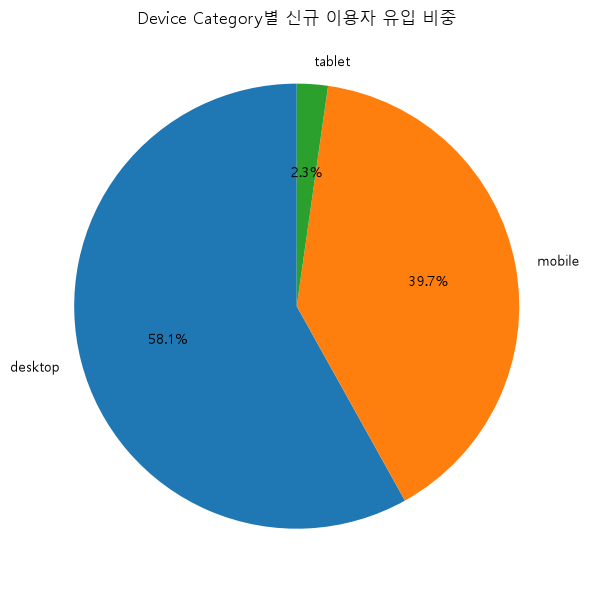

In [ ]:
from google.cloud import bigquery
import matplotlib.pyplot as plt

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
  device.category AS device_category,
  COUNT(DISTINCT user_pseudo_id) AS new_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
  AND event_name = 'first_visit'
GROUP BY device_category
ORDER BY new_users DESC
"""

df = client.query(query).to_dataframe()
print(df)

# 파이그래프
plt.figure(figsize=(6, 6))
plt.pie(
    df["new_users"],
    labels=df["device_category"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("디바이스별 총 신규 이용자 유입 비중")
plt.axis("equal")
plt.tight_layout()
plt.show()

### 주별 디바이스별 주간 신규 이용자 유입 누적 막대 그래프

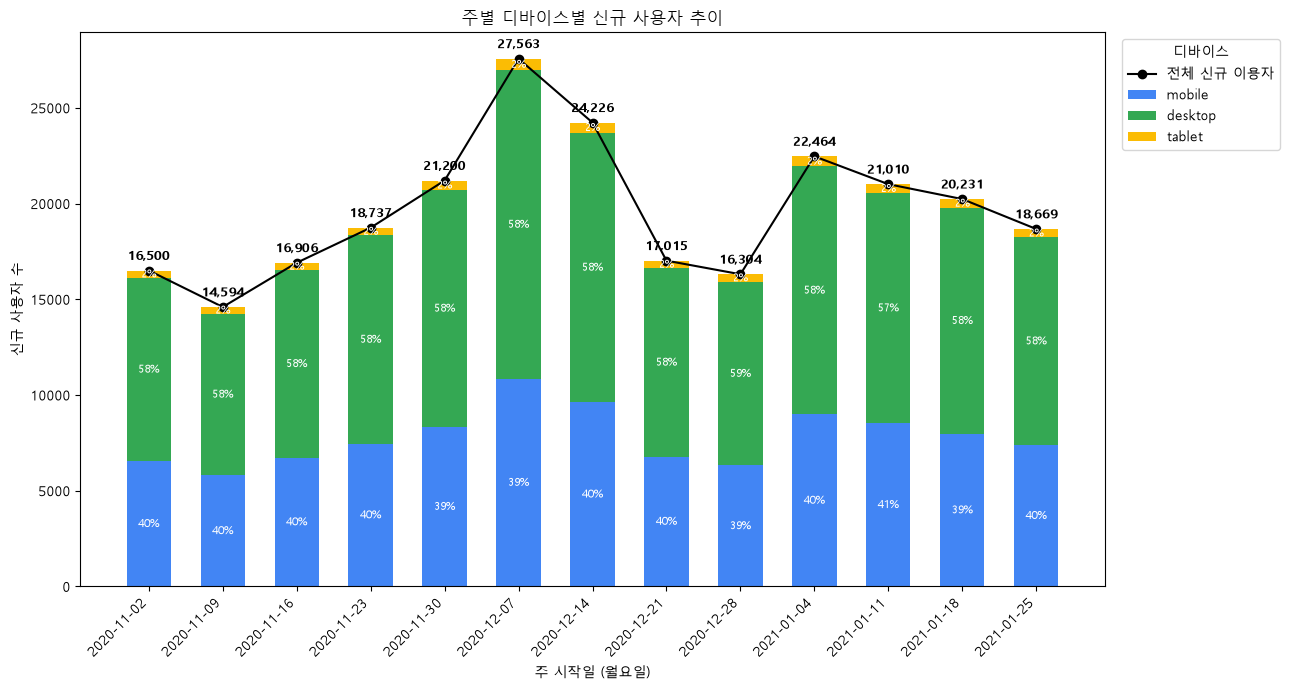

In [29]:
from google.cloud import bigquery
import matplotlib.pyplot as plt
import numpy as np

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
  DATE_TRUNC(PARSE_DATE('%Y%m%d', event_date), WEEK(MONDAY)) AS week_start,
  device.category AS device_category,
  COUNT(DISTINCT user_pseudo_id) AS new_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
  AND event_name = 'first_visit'
GROUP BY week_start, device_category
ORDER BY week_start
"""

df = client.query(query).to_dataframe()

pivot = df.pivot(index="week_start", columns="device_category", values="new_users").fillna(0)
pivot = pivot.sort_index()

device_order = [c for c in ["mobile", "desktop", "tablet"] if c in pivot.columns]
device_order += [c for c in pivot.columns if c not in device_order]
pivot = pivot[device_order]

colors = {
    "mobile": "#4285F4",
    "desktop": "#34A853",
    "tablet": "#FBBC04",
}
bar_colors = [colors.get(c, "#9AA0A6") for c in device_order]

total = pivot.sum(axis=1)
pct = pivot.div(total, axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 7))

# 카테고리형 x축: 채널 그래프와 동일하게 주 순서대로 균등 간격 배치
x_pos = np.arange(len(pivot))
x_labels = [d.strftime("%Y-%m-%d") for d in pivot.index]

bottom = np.zeros(len(pivot))

for device, color in zip(device_order, bar_colors):
    values = pivot[device].values
    ax.bar(x_pos, values, bottom=bottom, label=device, color=color, width=0.6)

    for i, (v, p) in enumerate(zip(values, pct[device].values)):
        if v > 0:
            ax.text(
                x_pos[i], bottom[i] + v / 2, f"{p:.0f}%",
                ha="center", va="center", fontsize=8, color="white"
            )
    bottom += values

ax.plot(x_pos, total, color="black", marker="o", linewidth=1.5, label="전체 신규 이용자")
for i, t in enumerate(total):
    ax.text(x_pos[i], t + total.max() * 0.02, f"{int(t):,}", ha="center", fontsize=9, fontweight="bold")

ax.set_title("주별 디바이스별 신규 사용자 추이")
ax.set_xlabel("주 시작일 (월요일)")
ax.set_ylabel("신규 사용자 수")
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.legend(title="디바이스", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## 디바이스별 분석 결과

### 검증 대상 가설
주별 신규 사용자 추이에서 관찰된 4개 구간 변동(특히 11/9~12/7 급등, 12/7~12/28 급락)의 원인이 **특정 채널 또는 특정 디바이스로의 쏠림**에 있을 가능성을 검증 항목으로 설정함.

### 디바이스별 분석 결과
- device.category(mobile/desktop/tablet) 기준 주별 구성비를 확인한 결과, 13주 전 구간에 걸쳐 desktop 57~58%, mobile 39~41%, tablet 2~3% 수준으로 **거의 변동이 없었음**.
- 급등 구간(11/9~12/7)과 급락 구간(12/7~12/28) 모두에서 디바이스 구성비가 유지됨 → 특정 디바이스가 변동을 주도한 것이 아니라, **전 디바이스에 걸쳐 비례적으로 증감**한 것으로 확인됨.

### 결론
**디바이스별 분석은 "특정 디바이스 쏠림이 변동의 원인"이라는 가설을 뒷받침하지 못함.** 오히려 디바이스 구성비의 안정성은, 관찰된 변동이 디바이스 축이 아닌 다른 요인(예: 계절적 소비 패턴, 채널 예산 집행, 지역별 소비 문화 등)에서 기인했을 가능성을 시사함.

### 다음 단계
디바이스 축에서 유의미한 설명력을 찾지 못한 만큼, 8/16에 세운 보조 가설대로 **지역(geo)별 분석**으로 넘어가 국가/지역별 신규 유입 추이가 동일한 4개 구간 패턴을 보이는지, 혹은 특정 지역에 편중된 변동인지 확인 예정.

---

# 지역별 신규 이용자 유입 분석

In [37]:
# geo.continent 기준 신규 이용자 집계
df_continent = get_grouped_counts("geo.continent", event_name="first_visit")
print(df_continent)

   continent  user_count
0   Americas      141122
1       Asia       60730
2     Europe       47785
3    Oceania        2658
4     Africa        2633
5  (not set)         588
6      Total      255516


In [38]:
df_sub_continent = get_grouped_counts("geo.sub_continent", event_name="first_visit")
print(df_sub_continent)

       sub_continent  user_count
0   Northern America      131209
1      Southern Asia       26239
2       Eastern Asia       17006
3     Western Europe       15666
4    Northern Europe       13204
5    Southern Europe       11502
6     Southeast Asia       10734
7     Eastern Europe        7413
8      South America        6617
9       Western Asia        6528
10   Central America        2665
11       Australasia        2658
12   Northern Africa        1168
13         Caribbean         631
14         (not set)         588
15    Western Africa         537
16   Southern Africa         443
17    Eastern Africa         431
18      Central Asia         223
19     Middle Africa          54
20             Total      255516


In [39]:
df_country = get_grouped_counts("geo.country", event_name="first_visit")
print(df_country)

            country  user_count
0     United States      112044
1             India       23943
2            Canada       19165
3    United Kingdom        8057
4            France        5090
..              ...         ...
105      Luxembourg          52
106        Honduras          50
107         Bahrain          48
108        Paraguay          47
109           Total      255516

[110 rows x 2 columns]


In [40]:
df_region = get_grouped_counts("geo.region", event_name="first_visit")
print(df_region)

           region  user_count
0       (not set)       24051
1      California       23724
2         Ontario        8328
3           Texas        8240
4        New York        7685
..            ...         ...
363     Friesland          46
364     Flevoland          46
365    Gangwon-do          46
366  Riau Islands          45
367         Total      255516

[368 rows x 2 columns]


In [41]:
df_metro = get_grouped_counts("geo.metro", event_name="first_visit")
print(df_metro)

       metro  user_count
0  (not set)      255516
1      Total      255516


In [42]:
df_city = get_grouped_counts("geo.city", event_name="first_visit")
print(df_city)

          city  user_count
0    (not set)      106172
1      Ashburn        5173
2     New York        4582
3    Singapore        3288
4       London        2637
..         ...         ...
628     McLean          45
629    Nanaimo          45
630      Tempe          44
631     Hoover          42
632      Total      255516

[633 rows x 2 columns]


## geo.* 컬럼 검증 과정 요약

### 검증 배경
`geo.*` 컬럼군에 대해 continent → sub_continent → country → region → metro → city 순으로 계층을 내려가며 결측률과 데이터 신뢰도를 검증함.

### 검증 결과 요약

| 컬럼 | (not set) 비율 | 판정 | 비고 |
|---|---|---|---|
| `geo.continent` | 0.2% (588명) | **채택** | 전체 구도 파악용 |
| `geo.sub_continent` | 0.2% (588명) | 채택 (검증/보조용) | 최종 시각화에서는 생략, 분석 근거로만 활용 |
| `geo.country` | 0% | **채택 (핵심 컬럼)** | 액션 가능한 인사이트 도출 가능 |
| `geo.region` | 9.4% (24,051명) | 제외 | IP 기반 지역 단위 정확도 한계로 결측 급증 |
| `geo.metro` | 100% (255,516명) | 제외 | 값이 전량 `(not set)` — 필드가 사실상 존재하지 않음 |
| `geo.city` | 41.6% (106,172명) | 제외 | 결측률이 region보다 훨씬 높아서 분석에 사용하기에 적합하지 않음 |

### 채택 컬럼 및 사용 방식
- **`geo.continent`**: 전체 지역 구도를 보여주는 최상위 요약 축으로 채택. Americas 55.2%, Asia 23.8%, Europe 18.7% 순으로 뚜렷한 격차 확인.
- **`geo.country`**: 실제 분석/시각화의 핵심 컬럼으로 채택. United States가 단독 43.9%(112,044명)를 차지하며, Americas 비중의 대부분이 사실상 미국 단일 국가에서 발생함을 확인.
- **`geo.sub_continent`**: 최종 시각화에는 포함하지 않되, "Americas의 92.9%가 Northern America(미국+캐나다)"라는 검증 근거로 활용.

### 제외 논리 (device.* 검증과의 일관성)
- `geo.metro`는 값이 완전히 채워지지 않아 컬럼이 의도한 의미를 전혀 전달하지 못함
- `geo.city`는 값이 채워지긴 하나, 도시 단위의 액션 인사이트를 도출하기에는 어려움이 있다고 판단
- `geo.region`은 완전 제외까지는 아니나, 9.4%라는 무시할 수 없는 결측률로 인해 핵심 분석 컬럼으로는 채택하지 않고 보조 참고용으로만 남김.

### 데이터 한계 참고
`geo.*` 필드는 GPS 기반 실측이 아닌 **IP 기반 추정**이며, VPN/프록시/모바일 네트워크 IP 할당 구조 등으로 인해 완전히 정확하지는 않음.

---

## Continent별 신규 이용자 파이차트

- `(not set)`(588명) 제외 후, Europe보다 신규 이용자 수가 적은 대륙(Oceania, Africa)을 **Other**로 통합함.
- 이에 따라 파이차트의 비율(%) 분모는 전체 신규 이용자(255,516명)가 아니라 **유효 지역이 확인된 254,928명** 기준으로 계산됨.
- 최종 카테고리: Americas, Asia, Europe, Other(Oceania+Africa) 4개.

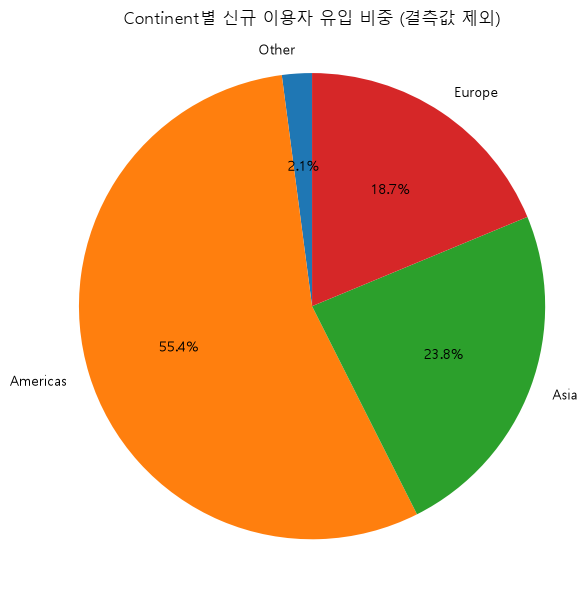

In [46]:
import matplotlib.pyplot as plt

df_continent = get_grouped_counts("geo.continent", event_name="first_visit")

# 합계 행("Total")과 "(not set)" 제외
df_plot = df_continent[
    (df_continent["continent"] != "Total") &
    (df_continent["continent"] != "(not set)")
].copy()

# Europe 값을 기준선으로 삼아, 그보다 작은 대륙은 Other로 묶기
europe_count = df_plot.loc[df_plot["continent"] == "Europe", "user_count"].values[0]

df_plot["group"] = df_plot.apply(
    lambda row: row["continent"] if row["user_count"] >= europe_count else "Other",
    axis=1
)

df_final = df_plot.groupby("group", as_index=False)["user_count"].sum()

# Other가 맨 마지막에 오도록 정렬 (나머지는 크기순)
df_final["sort_key"] = df_final["group"].apply(lambda x: -1 if x == "Other" else 0)
df_final = df_final.sort_values(
    by=["sort_key", "user_count"], ascending=[True, False]
).drop(columns="sort_key")

# 파이그래프
plt.figure(figsize=(6, 6))
plt.pie(
    df_final["user_count"],
    labels=df_final["group"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Continent별 신규 이용자 유입 비중 (결측값 제외)")
plt.axis("equal")
plt.tight_layout()
plt.show()

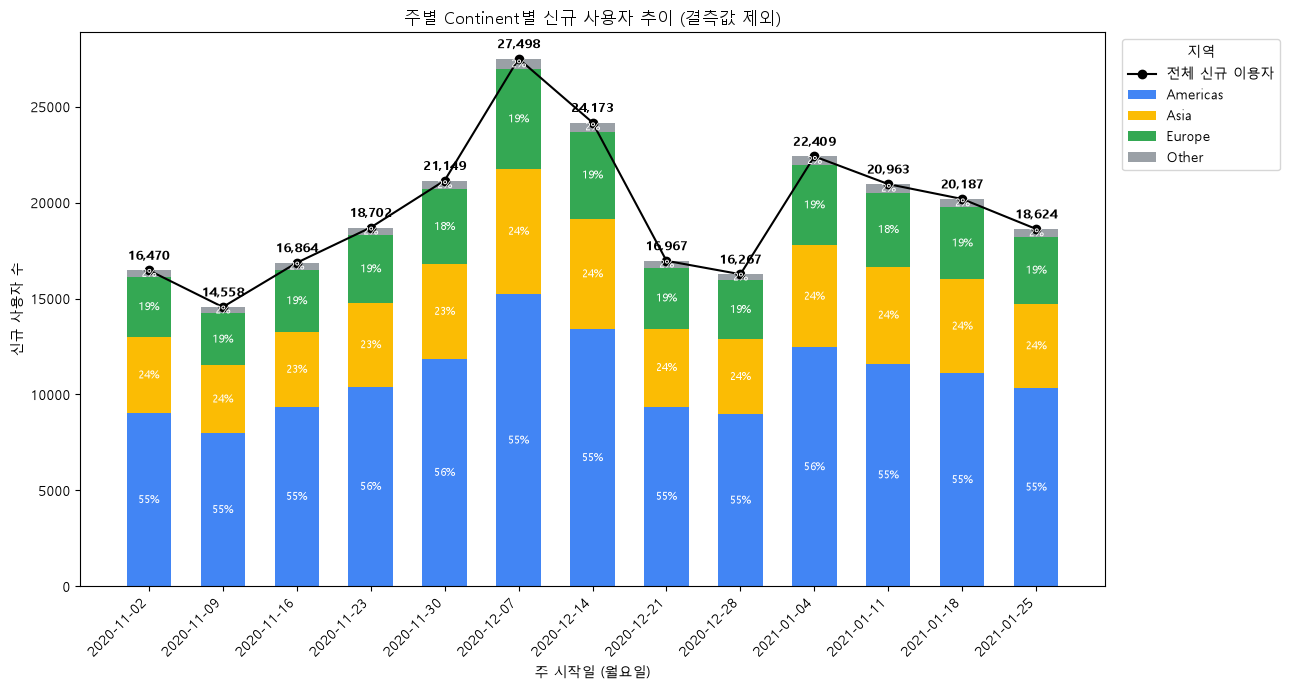

In [48]:
from google.cloud import bigquery
import matplotlib.pyplot as plt
import numpy as np

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
  DATE_TRUNC(PARSE_DATE('%Y%m%d', event_date), WEEK(MONDAY)) AS week_start,
  geo.continent AS continent,
  COUNT(DISTINCT user_pseudo_id) AS new_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
  AND event_name = 'first_visit'
  AND geo.continent != '(not set)'
GROUP BY week_start, continent
ORDER BY week_start
"""

df = client.query(query).to_dataframe()

# Europe보다 작은 대륙은 Other로 묶기 (전체 기준 Europe 총합 사용)
totals_by_continent = df.groupby("continent")["new_users"].sum()
europe_total = totals_by_continent["Europe"]

df["group"] = df["continent"].apply(
    lambda c: c if totals_by_continent[c] >= europe_total else "Other"
)

df_grouped = df.groupby(["week_start", "group"], as_index=False)["new_users"].sum()

# 주별 x 그룹 피벗
pivot = df_grouped.pivot(index="week_start", columns="group", values="new_users").fillna(0)
pivot = pivot.sort_index()

# 그룹 순서: 큰 그룹부터, Other는 마지막
group_order = [g for g in ["Americas", "Asia", "Europe"] if g in pivot.columns]
if "Other" in pivot.columns:
    group_order.append("Other")
pivot = pivot[group_order]

colors = {
    "Americas": "#4285F4",
    "Asia": "#FBBC04",
    "Europe": "#34A853",
    "Other": "#9AA0A6",
}
bar_colors = [colors.get(g, "#9AA0A6") for g in group_order]

total = pivot.sum(axis=1)
pct = pivot.div(total, axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 7))

x_pos = np.arange(len(pivot))
x_labels = [d.strftime("%Y-%m-%d") for d in pivot.index]

bottom = np.zeros(len(pivot))

for group, color in zip(group_order, bar_colors):
    values = pivot[group].values
    ax.bar(x_pos, values, bottom=bottom, label=group, color=color, width=0.6)

    for i, (v, p) in enumerate(zip(values, pct[group].values)):
        if v > 0:
            ax.text(
                x_pos[i], bottom[i] + v / 2, f"{p:.0f}%",
                ha="center", va="center", fontsize=8, color="white"
            )
    bottom += values

ax.plot(x_pos, total, color="black", marker="o", linewidth=1.5, label="전체 신규 이용자")
for i, t in enumerate(total):
    ax.text(x_pos[i], t + total.max() * 0.02, f"{int(t):,}", ha="center", fontsize=9, fontweight="bold")

ax.set_title("주별 Continent별 신규 사용자 추이 (결측값 제외)")
ax.set_xlabel("주 시작일 (월요일)")
ax.set_ylabel("신규 사용자 수")
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.legend(title="지역", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

### country별 총 신규 이용자 유입 비율

              국가  신규 이용자 수  비율(%)
0  United States    112044  44.21
1          India     23943   9.45
2         Canada     19165   7.56
3          Other     98309  38.79


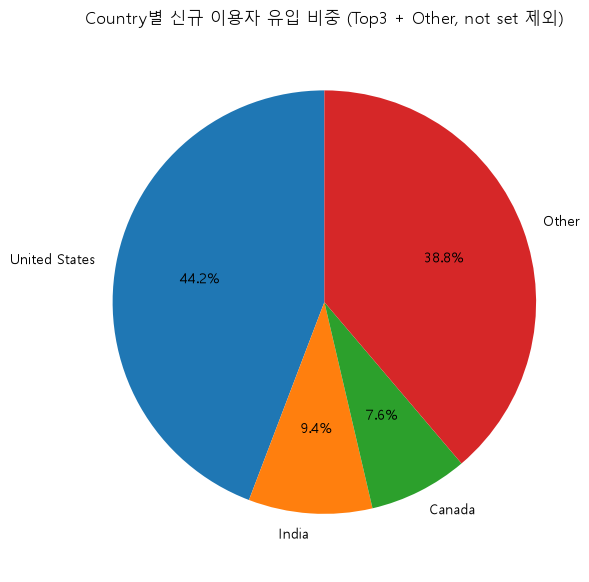

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

df_country = get_grouped_counts("geo.country", event_name="first_visit")

# 합계 행("Total")과 "(not set)" 제외
df_plot = df_country[
    (df_country["country"] != "Total") &
    (df_country["country"] != "(not set)")
].copy()

# 신규 이용자 수 기준 내림차순 정렬
df_plot = df_plot.sort_values("user_count", ascending=False).reset_index(drop=True)

# Top3 국가는 개별 유지, 4위부터는 Other로 묶기
top3 = df_plot.iloc[:3].copy()
other_sum = df_plot.iloc[3:]["user_count"].sum()

other_row = pd.DataFrame([{"country": "Other", "user_count": other_sum}])
df_final = pd.concat([top3, other_row], ignore_index=True)

# 비율(%) 계산
df_final["비율(%)"] = (df_final["user_count"] / df_final["user_count"].sum() * 100).round(2)
df_final_display = df_final.rename(columns={"country": "국가", "user_count": "신규 이용자 수"})

pd.set_option("display.float_format", "{:.2f}".format)
print(df_final_display)

# 파이차트
plt.figure(figsize=(6, 6))
plt.pie(
    df_final["user_count"],
    labels=df_final["country"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Country별 신규 이용자 유입 비중 (Top3 + Other, not set 제외)")
plt.axis("equal")
plt.tight_layout()
plt.show()

### 주별 디바이스별 주간 신규 이용자 유입 누적 막대 그래프

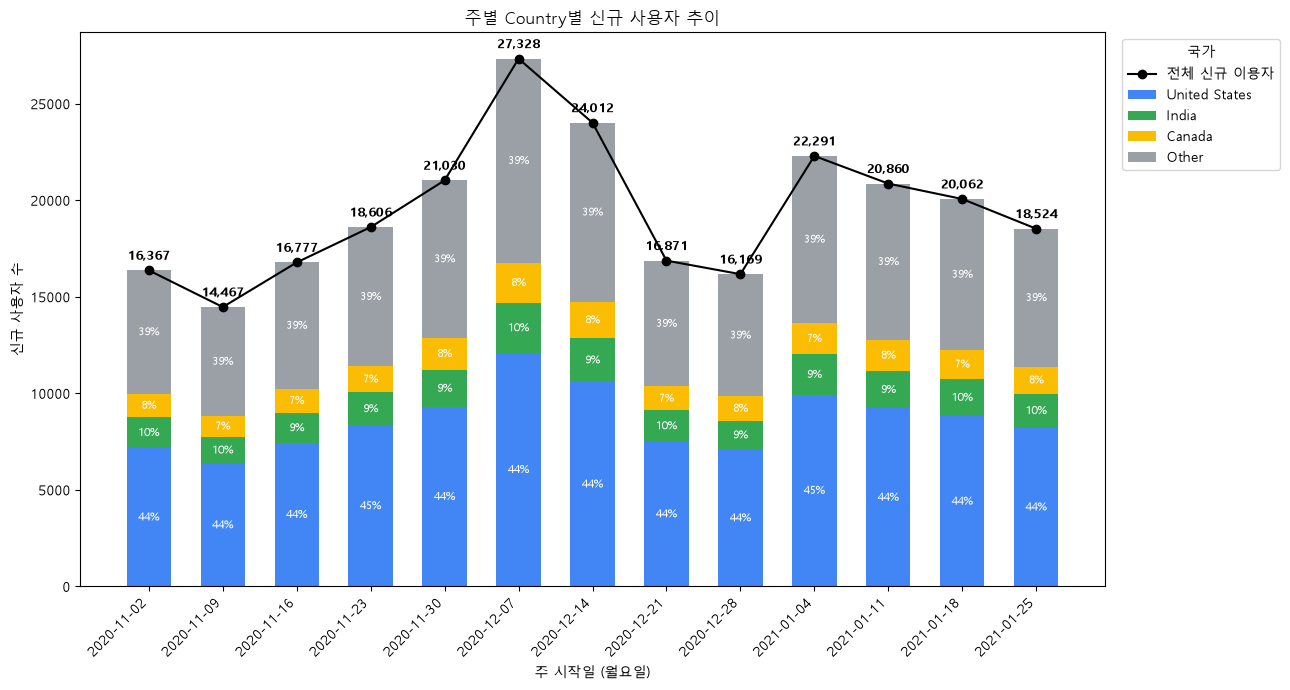

In [53]:
from google.cloud import bigquery
import matplotlib.pyplot as plt
import numpy as np

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
  DATE_TRUNC(PARSE_DATE('%Y%m%d', event_date), WEEK(MONDAY)) AS week_start,
  geo.country AS country,
  COUNT(DISTINCT user_pseudo_id) AS new_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
  AND event_name = 'first_visit'
  AND geo.country != '(not set)'
GROUP BY week_start, country
ORDER BY week_start
"""

df = client.query(query).to_dataframe()

# 전체 기간 기준 Top3 국가 산출
totals_by_country = df.groupby("country")["new_users"].sum().sort_values(ascending=False)
top3_countries = totals_by_country.index[:3].tolist()

df["group"] = df["country"].apply(lambda c: c if c in top3_countries else "Other")

df_grouped = df.groupby(["week_start", "group"], as_index=False)["new_users"].sum()

# 주별 x 그룹 피벗
pivot = df_grouped.pivot(index="week_start", columns="group", values="new_users").fillna(0)
pivot = pivot.sort_index()

# 그룹 순서: Top3(크기순) 먼저, Other는 마지막
group_order = [c for c in top3_countries if c in pivot.columns]
if "Other" in pivot.columns:
    group_order.append("Other")
pivot = pivot[group_order]

palette = ["#4285F4", "#34A853", "#FBBC04", "#9AA0A6"]
bar_colors = palette[:len(group_order)]

total = pivot.sum(axis=1)
pct = pivot.div(total, axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 7))

x_pos = np.arange(len(pivot))
x_labels = [d.strftime("%Y-%m-%d") for d in pivot.index]

bottom = np.zeros(len(pivot))

for group, color in zip(group_order, bar_colors):
    values = pivot[group].values
    ax.bar(x_pos, values, bottom=bottom, label=group, color=color, width=0.6)

    for i, (v, p) in enumerate(zip(values, pct[group].values)):
        if v > 0:
            ax.text(
                x_pos[i], bottom[i] + v / 2, f"{p:.0f}%",
                ha="center", va="center", fontsize=8, color="white"
            )
    bottom += values

ax.plot(x_pos, total, color="black", marker="o", linewidth=1.5, label="전체 신규 이용자")
for i, t in enumerate(total):
    ax.text(x_pos[i], t + total.max() * 0.02, f"{int(t):,}", ha="center", fontsize=9, fontweight="bold")

ax.set_title("주별 Country별 신규 사용자 추이")
ax.set_xlabel("주 시작일 (월요일)")
ax.set_ylabel("신규 사용자 수")
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.legend(title="국가", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# Acquisition 단계 분석 결과 요약
### Google 머천다이즈 스토어 — 2020년 11월 ~ 2021년 1월

---

## 한눈에 보는 핵심 결론

**신규 방문자가 급증하거나 급감할 때, 특정 유입 채널·기기·지역이 원인이 아니였음.**
채널, 디바이스, 대륙, 국가 — 네 가지 기준으로 각각 확인했지만, 방문자 수가 늘든 줄든 그 구성 비율은 거의 그대로 유지됨. 즉 특정 마케팅 채널이나 특정 지역을 강화해서 성장을 이끈 것이 아니라, **전 세계 모든 유입 경로에서 동시에 방문자가 늘고 줄었다**는 의미.

이는 곧 최근 시즌(블랙프라이데이, 크리스마스, 연초) 방문자 변동이 **특정 마케팅 활동의 성과가 아니라, 쇼핑 시즌 자체에 따른 자연스러운 수요 변화**였을 가능성이 높다는 것을 의미함.

---

## 확인한 내용

| 구분 | 확인 결과 |
|---|---|
| 유입 채널 (검색, 직접 방문, 광고 등) | 방문자 수와 무관하게 채널별 비중 거의 고정 |
| 기기 (PC / 모바일 / 태블릿) | 방문자 수와 무관하게 기기별 비중 거의 고정 |
| 대륙 (아메리카/아시아/유럽 등) | 방문자 수와 무관하게 대륙별 비중 거의 고정 |
| 국가 (미국/인도/캐나다 등) | 방문자 수와 무관하게 국가별 비중 거의 고정  |

---

## 비즈니스 관점에서 발견된 문제점

이번 분석 과정에서, 성장 원인 파악보다 더 시급한 **마케팅 성과 측정 인프라의 공백**을 발견함.

1. **광고비 데이터 부재** — 어떤 채널에 얼마를 썼는지 알 수 없어, 광고 투자 대비 효과(ROI/CAC)를 전혀 계산할 수 없음.
2. **캠페인 식별 정보 부재** — 실제 광고 캠페인명이 기록되지 않아, 어떤 광고 소재나 프로모션이 효과적이었는지 추적이 불가능함.
3. **SNS(소셜미디어) 유입 채널이 사실상 없음** — 소셜 마케팅이 안 하고 있는 것인지, 하고 있는데 추적이 안 되는 것인지조차 구분할 수 없는 상태임.
4. **유입 경로 미상(Unassigned) 18%** — 신규 방문자 5명 중 1명 가까이가 "어디서 왔는지 알 수 없음"으로 집계되고 있음.

**즉, 지금 상태로는 "어떤 마케팅이 효과적인지" 자체를 판단할 데이터가 부족함.**

---

## 결론 및 다음 단계 제안

- 이번 급증/급감은 **시즌성 수요 변화**로 잠정 결론짓고, Acquisition(유입) 단계 분석은 마무리함.
- 향후 유의미한 성장 전략을 세우려면, **채널·캠페인 성과를 정확히 측정할 수 있는 트래킹 체계 정비**가 우선적으로 필요함
- 다음 분석 단계인 **Activation(활성화)** 에서는 "유입된 방문자가 실제 구매·핵심 행동으로 얼마나 이어지는가"를 채널·기기·지역별로 교차 분석하여, 이번 단계에서 찾지 못한 실질적인 개선 포인트를 도출할 예정임.